In [7]:
# 1. Возвращаемся в корень Colab
%cd /content

# 2. Сносим старую папку со всеми потрохами намертво
!rm -rf /content/Pong-Game-Deep-Q-learning-RL-

# 3. Клонируем репозиторий с гитхаба С ЧИСТОГО ЛИСТА
!git clone https://github.com/egorzernin0305-rgb/Pong-Game-Deep-Q-learning-RL-.git

# 4. Переходим в новую чистую папку
%cd /content/Pong-Game-Deep-Q-learning-RL-

# 5. Ставим зависимости
!pip install -r requirements.txt

import numpy as np
from env_pong import PongEnv
from models import Baseline
from models import HumanPlayer
from models import DQN_StBaselines3
from models import MyDQN
import stable_baselines3
from stable_baselines3 import DQN
from mydqn_components import Q_network
import pandas as pd

/content
Cloning into 'Pong-Game-Deep-Q-learning-RL-'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 123 (delta 59), reused 68 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 4.67 MiB | 18.03 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/Pong-Game-Deep-Q-learning-RL-


In [16]:
dqn_best = DQN.load("saved_models/pong_dqn_1.2M.zip")

In [18]:
env_test = PongEnv(opponent=Baseline(),  render_mode = None , n_rounds=100)
agent = DQN_StBaselines3(model=dqn_best)
stats_st3 = env_test.demo(left_player=agent)

In [19]:
for key, element in stats_st3.items():
    print(f"{key} - {element}")

avg_round_steps - 747.3219178082192
avg_round_time - 12.455365296803652
avg_round_reward - 1.5080136464945528
variance_reward - 4.858811679909693
score - {'agent': 46, 'opponent': 100}
agent_win_rate - 0.3150684931506849
rounds_amount - 146


In [ ]:
my_dqn = MyDQN(q_network=Q_network())
my_dqn.load("pong_mydqn_700k")
env_test_mydqn = PongEnv(opponent=Baseline(),  render_mode = 'human', n_rounds=100)
stats = env_test_mydqn.demo()

In [ ]:
# тут то что сейчас нужно

In [8]:
my_dqn = MyDQN(q_network=Q_network())
my_dqn.pretrain_on_dataset(pd.read_csv("pong_datasets/pong_dataset_100000.csv"), n_epoch=1)

0.5296147980906608 - loss on 1-th epoch


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:

env_learning = PongEnv(opponent=Baseline(),  render_mode = None, n_rounds=100)
learning_stats = my_dqn.learn(total_timesteps= 700000, env=env_learning)

прошло 1 шагов
прошло 100001 шагов
прошло 200001 шагов
прошло 300001 шагов
прошло 400001 шагов
прошло 500001 шагов
прошло 600001 шагов


In [14]:
env_test = PongEnv(opponent=Baseline(),  render_mode = None, n_rounds=100)
stats_mydqn = env_test.demo(left_player=my_dqn)
for key, element in stats_mydqn.items():
    print(f"{key} - {element}")

avg_round_steps - 226.37142857142857
avg_round_time - 3.7728571428571427
avg_round_reward - -0.701550126808138
variance_reward - 0.3898423042958622
score - {'agent': 5, 'opponent': 100}
agent_win_rate - 0.047619047619047616
rounds_amount - 105


In [9]:
import torch
print(torch.cuda.is_available())

True


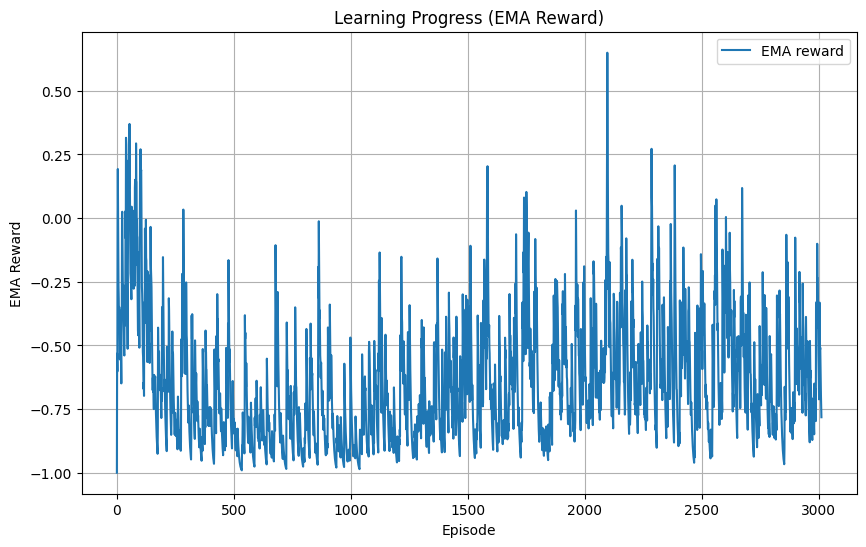

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(learning_stats, label='EMA reward')
plt.xlabel('Episode')
plt.ylabel('EMA Reward')
plt.title('Learning Progress (EMA Reward)')
plt.grid(True)
plt.legend()
plt.show()

In [13]:
from google.colab import files

# Сохраняем модель (веса q_network)
my_dqn.save("pong_mydqn_claude_700k")

# Скачиваем на компьютер
files.download("saved_models/pong_mydqn_claude_700k")

pd.DataFrame(learning_stats).to_csv("learning_stats_claude.csv", index=False)
files.download("learning_stats_claude.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>